In [1]:
from utils_impago import HarvestImpagoMatrix, HarvestConfig

# Configuración de cálculos de matrices

In [2]:
# Configuración de cálculo específico
cfg_exp = HarvestConfig() # BGI4+ predeterminado

cfg_ever = HarvestConfig(
    metric_mode="ever",
    ever_col="BGI4+_CONTEO_EVER",
    folio_col="folio",
    ever_den_mode="variable",  # default
)

# 1. Prueba de cálculo de matriz de %impago por montos

## 1.1.1 Matriz de % de impago

In [3]:
builder_exp = HarvestImpagoMatrix.from_excel("Saldo_cosechas_20251201.xlsx", config=cfg_exp)
builder_exp.run()

matriz_exp = builder_exp.get_matrix()
agg_exp = builder_exp.get_agg()

matriz_exp

MOB,1,2,3,4,5,6,7,8,9,10,...,32,33,34,35,36,37,38,39,40,41
cohorte,,,,,,,,,,,,,,,,,,,,,
2022-06-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0
2022-07-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,NaN
2022-08-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.845346,3.845346,3.845346,6.983685,6.983685,6.983685,6.983685,6.983685,NaN,NaN
2022-09-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.981889,3.981889,3.376777,4.708011,4.668025,4.493559,4.317245,NaN,NaN,NaN
2022-10-01,0.000000,0.000000,0.000000,0.089793,0.089793,0.089793,0.089793,0.089793,0.089793,0.089793,...,0.089793,0.089793,0.089793,0.089793,0.089793,3.933168,NaN,NaN,NaN,NaN
2022-11-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.396843,2.314382,2.314382,...,2.978173,2.978173,2.978173,2.978173,3.941295,NaN,NaN,NaN,NaN,NaN
2022-12-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,9.566653,9.566653,9.566653,9.566653,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.958418,3.227492,3.227492,...,10.029882,9.113574,9.080338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.175844,1.040205,1.040205,1.040205,...,5.121605,5.121605,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 1.1.2 Matriz de agregados BGI4+

In [4]:
agg_exp

,cohorte,MOB,bgi_sum,monto_sum,pct_impago
0,2022-06-01,1,0.00,1.076772e+05,0.000000
1,2022-06-01,2,0.00,1.076772e+05,0.000000
2,2022-06-01,3,0.00,1.076772e+05,0.000000
3,2022-06-01,4,0.00,1.076772e+05,0.000000
4,2022-06-01,5,0.00,1.076772e+05,0.000000
...,...,...,...,...,...
856,2025-08-01,2,0.00,4.522629e+07,0.000000
857,2025-08-01,3,0.00,4.522629e+07,0.000000
858,2025-09-01,1,345717.99,4.970562e+07,0.695531
859,2025-09-01,2,597468.98,4.970562e+07,1.202015


## 1.1.3 Guardado de matriz

In [5]:
builder_exp.save_matrix("output_data/Matriz_impago_cosecha_exp.xlsx", fmt="excel")
builder_exp.save_agg("output_data/Agg_impago_long_exp.csv", fmt="csv")

Archivo guardado en: output_data/Matriz_impago_cosecha_exp.xlsx
Archivo guardado en: output_data/Agg_impago_long_exp.csv


# 1.2 Visualizaciones con Heatmap

## 1.2.1 Matriz completa horizontal

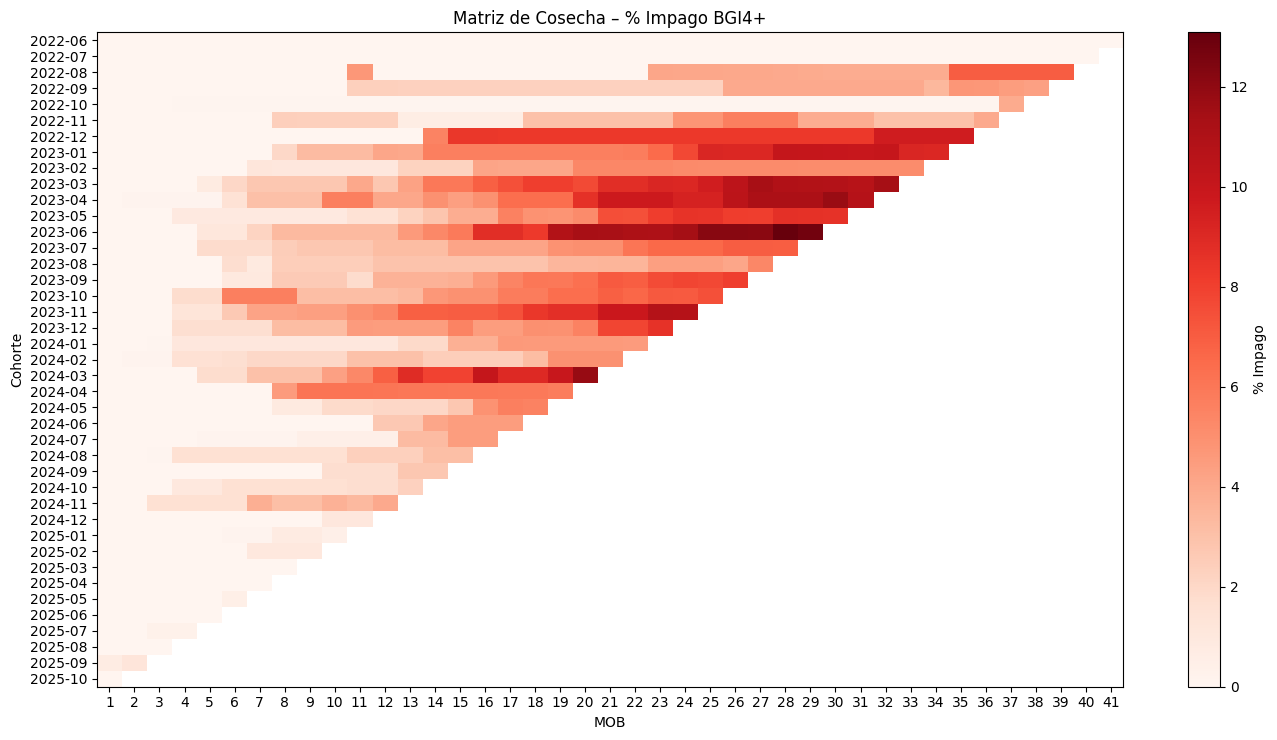

In [6]:
# Clásico (Y=cohorte, X=MOB)
builder_exp.plot_heatmap_classic()

## 1.2.2 Matriz completa vertical

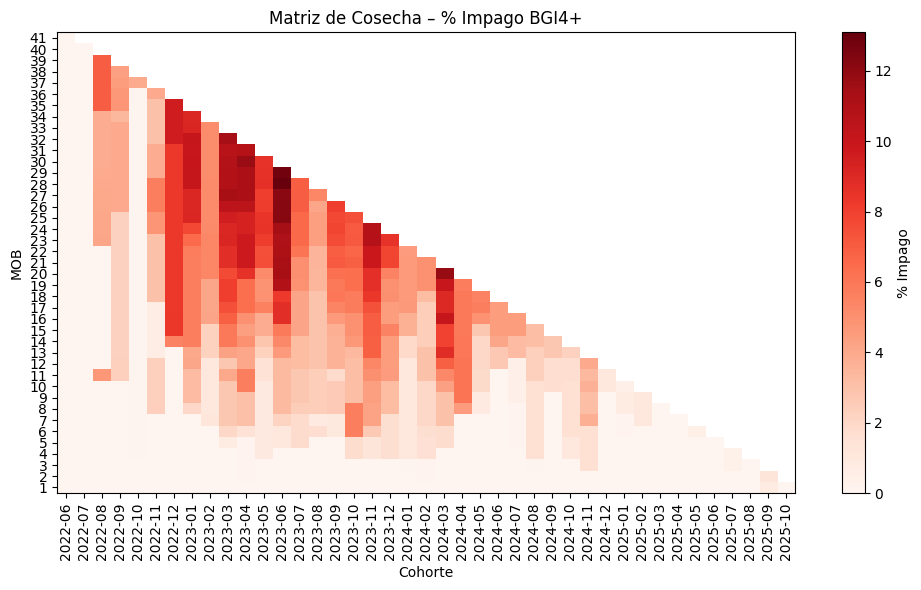

In [7]:
# Vertical (X=cohorte, Y=MOB, origen lower)
builder_exp.plot_heatmap_vertical()

## 1.2.3 Un solo cohorte

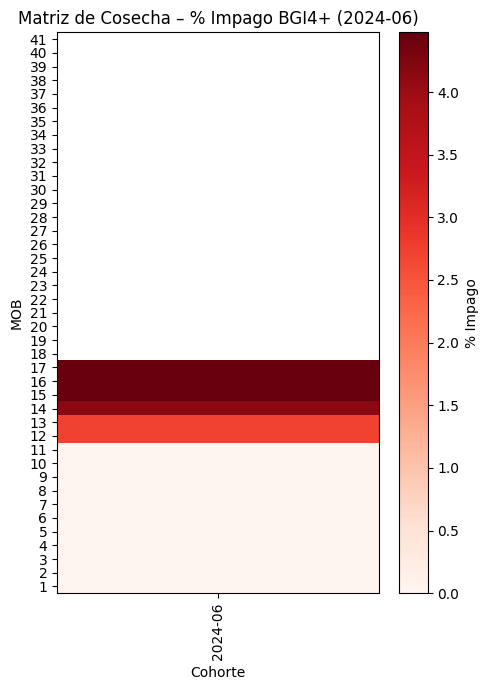

In [8]:
# Un cohorte
builder_exp.plot_heatmap_vertical(cohort_start="2024-06", cohort_end="2024-06")

## 1.2.4 Heatmap desde un cohorte específico hasta el final

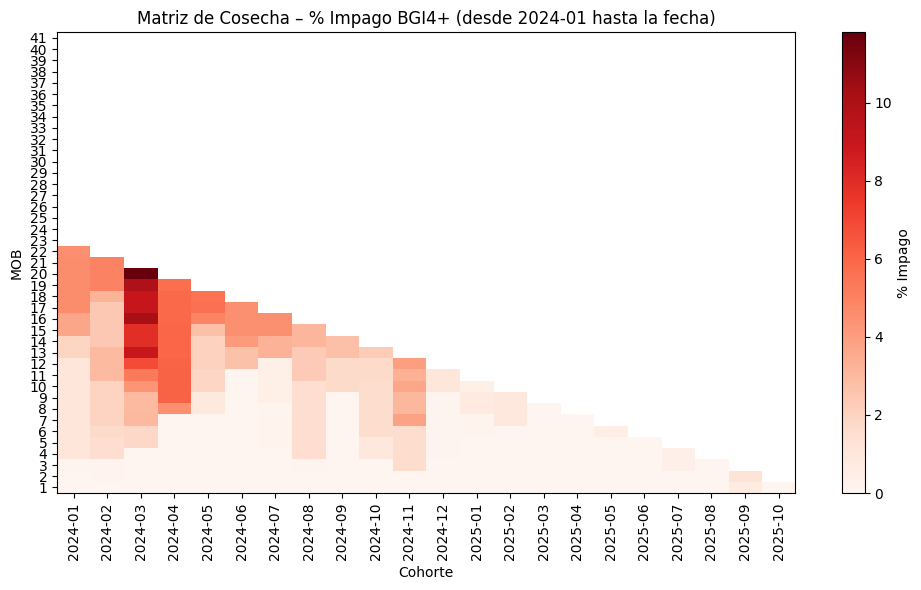

In [9]:
# HeatMap desde el inicio hasta el final
builder_exp.plot_heatmap_vertical(cohort_start="2024-01")

## 1.2.5 Heatmap de un rango de cohortes

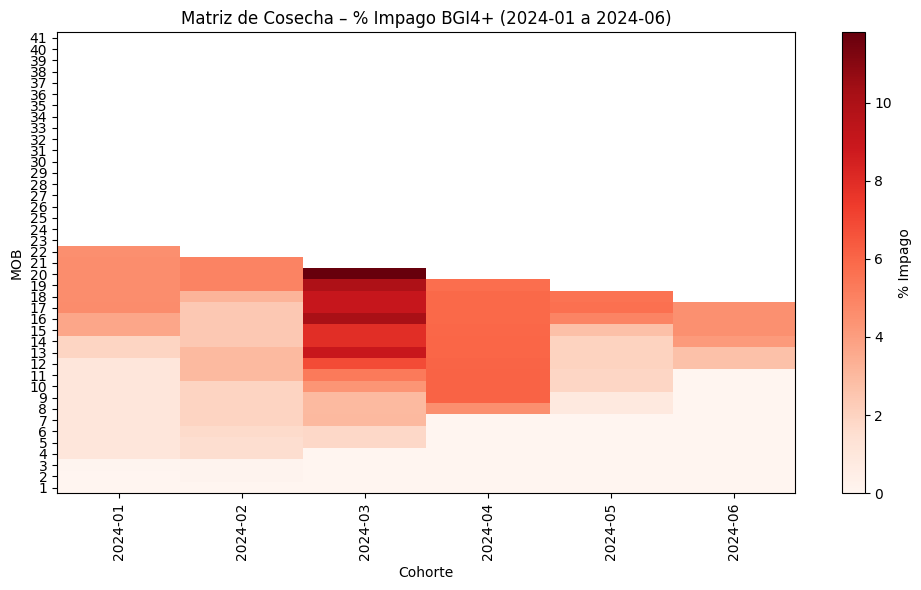

In [10]:
# Rango
builder_exp.plot_heatmap_vertical(cohort_start="2024-01", cohort_end="2024-06")

# 1.3 Cruvas de % de impago de cosechas

## 1.3.1 Todas las cruvas

In [11]:
# Curvas de todos los cohortes
builder_exp.plot_cohort_curves_all()

## 1.3.2 Top 10 con mayor % de impago respecto al último MOB

In [12]:
# Top 10 por último MOB disponible
builder_exp.plot_top_cohort_curves(mode="last", top_n=10)

## 1.3.3 Top 10 con mayor % de impago respecto al promedio de los últimos "n" MOB

In [13]:
# Top 10 por promedio de últimos N MOB
builder_exp.plot_top_cohort_curves(mode="tail_mean", top_n=10, tail_n=3)

## 1.3.4 Top 10 con mayor % de impago respecto a un MOB fijo

In [14]:
# Top 10 por MOB fijo
builder_exp.plot_top_cohort_curves(mode="mob", top_n=10, mob_k=6)

## 1.3.5 Top 10 con mayor % de impago respecto a un MOB fijo y para un rango espcífico de cohortes

In [15]:
# Solo un rango de cohortes
builder_exp.plot_top_cohort_curves(mode="mob", top_n=10, mob_k=6, cohort_start="2024-01", cohort_end="2024-12")

# 1.4 Curvas promedio % de impago del portafolio

## 1.4.1 Curva de promedio simple de % impago respecto a todo el portafolio

In [16]:
# Promedio simple (cada cohorte pesa igual)
builder_exp.plot_portfolio_curve_mean()

## 1.4.2 Curva de promedio simple de % impago respecto a un cohorte específico hasta el final del portafolio

In [17]:
# Solo cohortes recientes
builder_exp.plot_portfolio_curve_mean(cohort_start="2024-01")

# 2. Prueba de cálculo de matriz de %impago por conteos EVER

## 2.1.1 Matriz de % de impago

In [18]:
builder_ever = HarvestImpagoMatrix.from_excel("Saldo_cosechas_20251201.xlsx", config=cfg_ever)
builder_ever.run()

matriz_ever = builder_ever.get_matrix()
agg_ever = builder_ever.get_agg()

matriz_ever

MOB,1,2,3,4,5,6,7,8,9,10,...,32,33,34,35,36,37,38,39,40,41
cohorte,,,,,,,,,,,,,,,,,,,,,
2022-06-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.0
2022-07-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,NaN
2022-08-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,5.000000,5.000000,5.000000,10.000000,10.000000,10.000000,10.000000,10.0,NaN,NaN
2022-09-01,2.777778,2.777778,2.777778,2.777778,2.777778,2.777778,2.777778,2.777778,2.777778,2.777778,...,8.333333,8.333333,8.333333,11.111111,11.111111,11.111111,11.111111,NaN,NaN,NaN
2022-10-01,0.000000,0.000000,0.000000,2.439024,2.439024,2.439024,2.439024,2.439024,2.439024,2.439024,...,2.439024,2.439024,2.439024,2.439024,2.439024,7.317073,NaN,NaN,NaN,NaN
2022-11-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.941176,2.941176,2.941176,...,11.764706,11.764706,11.764706,11.764706,14.705882,NaN,NaN,NaN,NaN,NaN
2022-12-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,8.695652,8.695652,8.695652,8.695652,NaN,NaN,NaN,NaN,NaN,NaN
2023-01-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.470588,2.941176,2.941176,...,14.705882,14.705882,14.705882,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023-02-01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.219512,2.439024,2.439024,2.439024,...,6.097561,6.097561,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 2.1.2 Matriz de agregados BGI4+

In [19]:
agg_ever

,cohorte,MOB,ever_sum,folio_den,pct_ever
0,2022-06-01,1,0,1,0.000000
1,2022-06-01,2,0,1,0.000000
2,2022-06-01,3,0,1,0.000000
3,2022-06-01,4,0,1,0.000000
4,2022-06-01,5,0,1,0.000000
...,...,...,...,...,...
856,2025-08-01,2,0,259,0.000000
857,2025-08-01,3,0,259,0.000000
858,2025-09-01,1,3,289,1.038062
859,2025-09-01,2,4,289,1.384083


## 2.1.3 Guardado de matriz

In [20]:
builder_exp.save_matrix("output_data/Matriz_impago_cosecha_ever.xlsx", fmt="excel")
builder_exp.save_agg("output_data/Agg_impago_long_ever.csv", fmt="csv")

Archivo guardado en: output_data/Matriz_impago_cosecha_ever.xlsx
Archivo guardado en: output_data/Agg_impago_long_ever.csv


# Agregar funcionalidad para guardar en cualquier path

# 2.2 Visualizaciones con Heatmap

## 2.2.1 Matriz completa horizontal

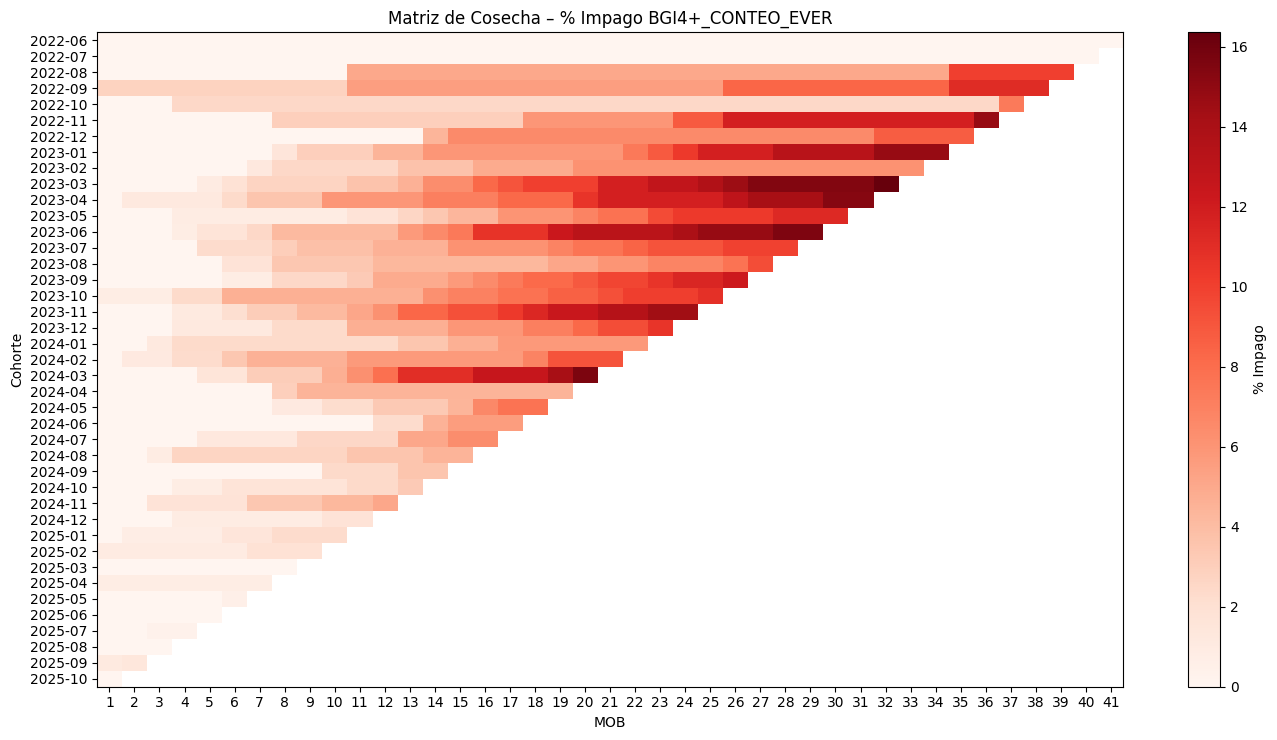

In [21]:
# Clásico (Y=cohorte, X=MOB)
builder_ever.plot_heatmap_classic()

## 2.2.2 Matriz completa vertical

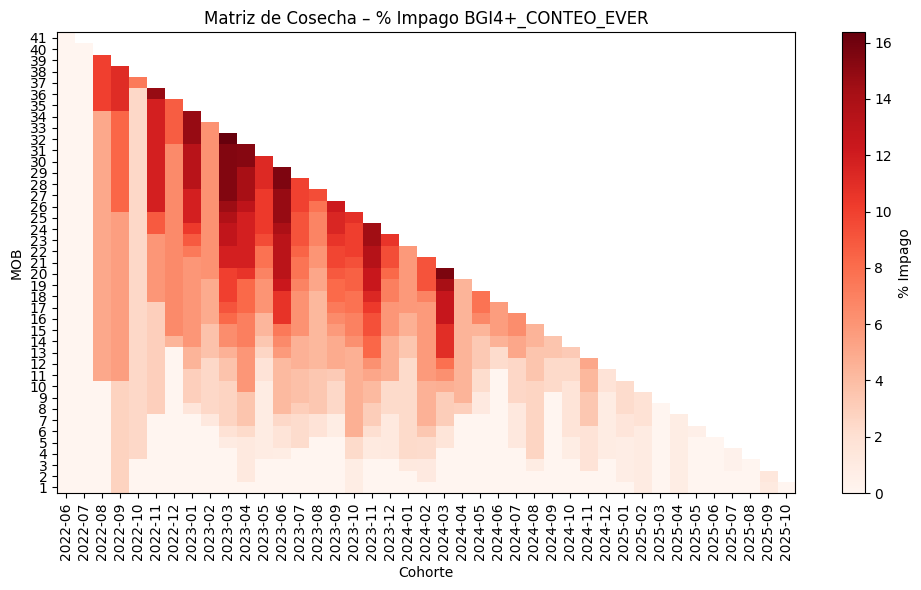

In [22]:
# Vertical (X=cohorte, Y=MOB, origen lower)
builder_ever.plot_heatmap_vertical()

## 2.2.3 Un solo cohorte

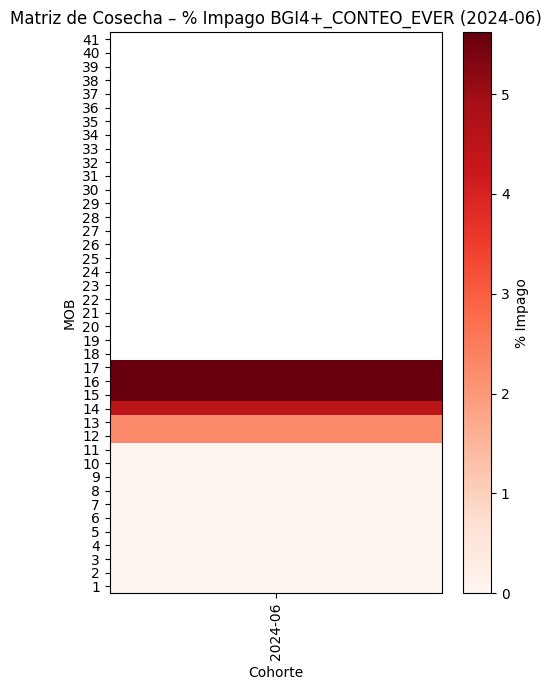

In [23]:
builder_ever.plot_heatmap_vertical(cohort_start="2024-06", cohort_end="2024-06")

## 2.2.4 Heatmap desde un cohorte específico hasta el final

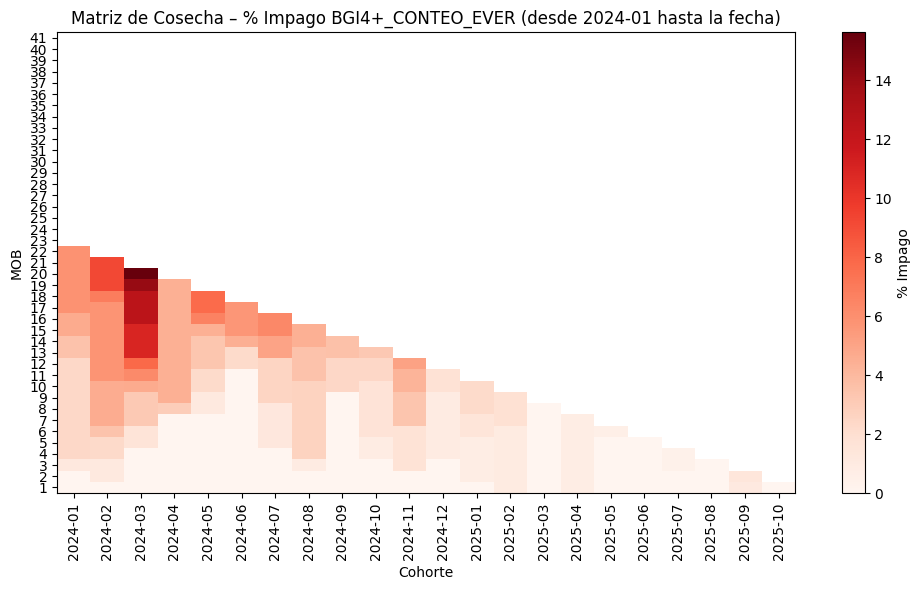

In [24]:
# HeatMap desde el inicio hasta el final
builder_ever.plot_heatmap_vertical(cohort_start="2024-01")

## 2.2.5 Heatmap de un rango de cohortes

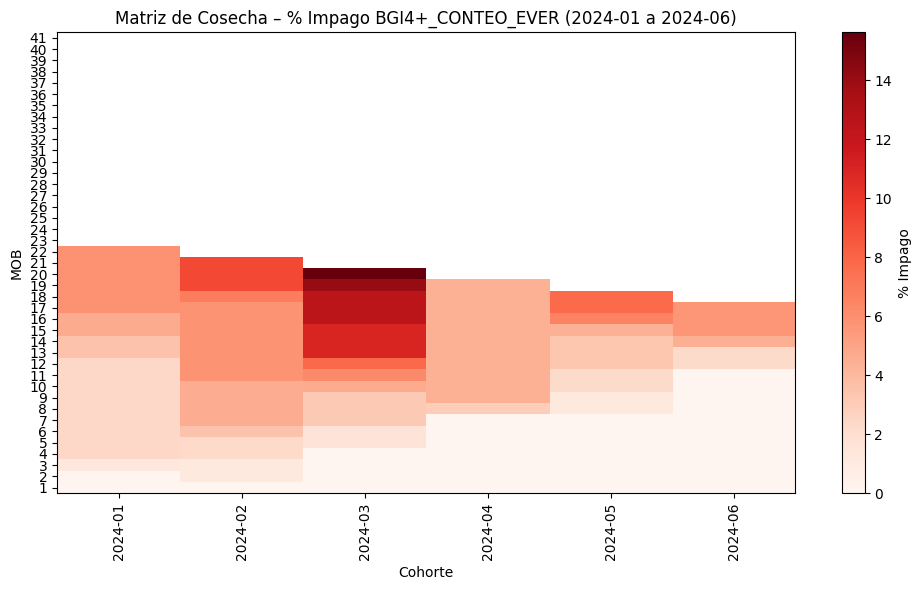

In [25]:
# Rango
builder_ever.plot_heatmap_vertical(cohort_start="2024-01", cohort_end="2024-06")

# 2.3 Cruvas de % de impago de cosechas

## 2.3.1 Todas las cruvas

In [26]:
# Curvas de todos los cohortes
builder_ever.plot_cohort_curves_all()

## 2.3.2 Top 10 con mayor % de impago respecto al último MOB

In [27]:
# Top 10 por último MOB disponible
builder_ever.plot_top_cohort_curves(mode="last", top_n=10)

## 2.3.3 Top 10 con mayor % de impago respecto al promedio de los últimos "n" MOB

In [28]:
# Top 10 por promedio de últimos N MOB
builder_ever.plot_top_cohort_curves(mode="tail_mean", top_n=10, tail_n=3)

## 2.3.4 Top 10 con mayor % de impago respecto a un MOB fijo

In [29]:
# Top 10 por MOB fijo
builder_ever.plot_top_cohort_curves(mode="mob", top_n=10, mob_k=6)

## 2.3.5 Top 10 con mayor % de impago respecto a un MOB fijo y para un rango espcífico de cohortes

In [30]:
# Solo un rango de cohortes
builder_ever.plot_top_cohort_curves(mode="mob", top_n=10, mob_k=6, cohort_start="2024-01", cohort_end="2024-12")

# 2.4 Curvas promedio % de impago del portafolio

## 2.4.1 Curva de promedio simple de % impago respecto a todo el portafolio

In [31]:
# Promedio simple (cada cohorte pesa igual)
builder_ever.plot_portfolio_curve_mean()

# Revisar de donde saca los valores este plot

## 2.4.2 Curva de promedio simple de % impago respecto a un cohorte específico hasta el final del portafolio

In [32]:
# Solo cohortes recientes
builder_ever.plot_portfolio_curve_mean(cohort_start="2024-01")